#**Martes 10 de marzo 2026**

###- Julieta Madrigal Flores
###- Rodolfo Del Castillo Wilches

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import yfinance as yf


#Objetivo
Explorar cómo cambian las simulaciones de precios cuando se modifican los parámetros del modelo.

Deberás variar un parámetro a la vez, manteniendo los demás constantes (ceteris paribus) para entender cómo cada variable afecta el comportamiento del activo y el valor de la opción.

Usando el mismo activo que usamos, con los mismos parámetros usados en clase, también disponibles en Notion.

# Parámetros del modelo
Los parámetros que pueden modificar el precio de una opción son:

Parámetro	Significado
- S0	Precio inicial del activo
- K	Precio de ejercicio
- σ	Volatilidad
- r	Tasa libre de riesgo
- T	Tiempo al vencimiento
- N	Número de simulaciones


#**Parte 1 — Volatilidad**
Modificar únicamente σ.

Probar con:

- σ = 0.01
- σ = 0.10
- σ = 0.20
- σ = 0.40

Graficar:

Distribución del precio Spot final en los 4 escenarios



In [ ]:
ticker = "SPY"
data = yf.download(ticker, start ="2022-01-01", end="2026-03-10")["Close"]
data

/tmp/ipykernel_406/668579730.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start ="2022-01-01", end="2026-03-10")["Close"]
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2022-01-03,451.875092
2022-01-04,451.723785
2022-01-05,443.049713
2022-01-06,442.633545
2022-01-07,440.883545
...,...
2026-03-03,680.330017
2026-03-04,685.130005
2026-03-05,681.309998


/tmp/ipykernel_406/3009997866.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data.iloc[-1])       # Tomamos el último precio de cierre como precio inicial y lo convertimos a float


Precio inicial (S0) de SPY: 678.27


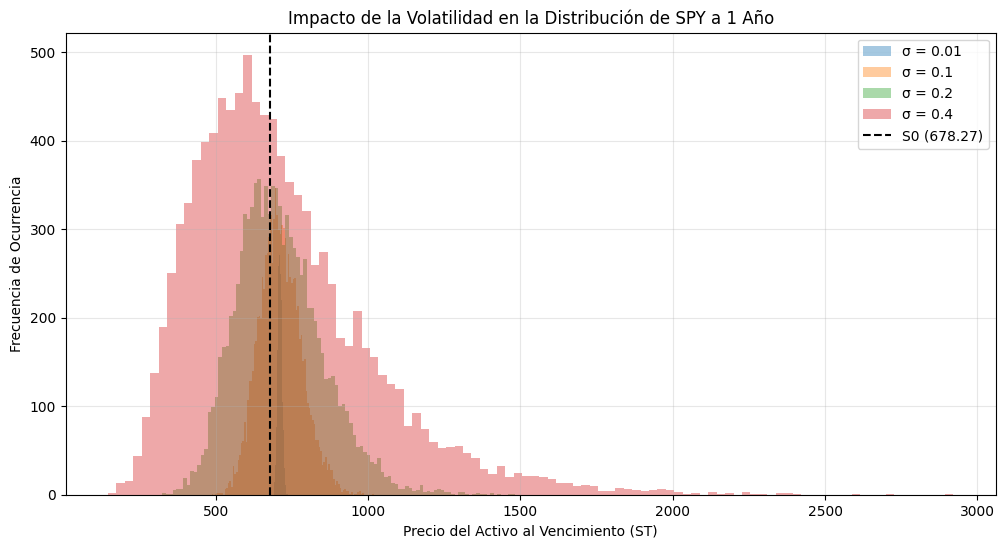

In [ ]:
# Parámetros Base
S0 = float(data.iloc[-1])       # Tomamos el último precio de cierre como precio inicial y lo convertimos a float
K = S0                   # Suponemos una opción At-the-Money (K = S0)
r = 0.045                # Tasa libre de riesgo (aprox 4.5% anual en 2026)
T = 1.0                  # 1 año de horizonte
N = 10000                # Número de simulaciones
sigmas = [0.01, 0.10, 0.20, 0.40]

# Contenedores para resultados
resultados_finales = []
plt.figure(figsize=(12, 6))

print(f"Precio inicial (S0) de {ticker}: {S0:.2f}")

# 2. Bucle de Simulación Ceteris Paribus (Variando Sigma)
for sigma in sigmas:
    # Generación de trayectorias (Movimiento Browniano Geométrico)
    Z = np.random.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # Cálculo de Payoffs y Descuento al Valor Presente
    call_prices = np.exp(-r * T) * np.maximum(ST - K, 0)
    put_prices = np.exp(-r * T) * np.maximum(K - ST, 0)

    # Guardar promedios (Precio de la opción)
    resultados_finales.append({
        "Sigma (σ)": sigma,
        "Precio Call": np.mean(call_prices),
        "Precio Put": np.mean(put_prices)
    })

    # Graficar Distribución
    plt.hist(ST, bins=100, alpha=0.4, label=f'σ = {sigma}')

# 3. Formateo de Gráfica
plt.axvline(S0, color='black', linestyle='--', label=f'S0 ({S0:.2f})')
plt.title(f'Impacto de la Volatilidad en la Distribución de {ticker} a 1 Año')
plt.xlabel('Precio del Activo al Vencimiento (ST)')
plt.ylabel('Frecuencia de Ocurrencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Generación de Tablas
df_resultados = pd.DataFrame(resultados_finales)



Crear una tabla con el valor de la call para cada escenario

In [ ]:
print("\n### TABLA DE VALORES: OPCIÓN CALL ###")
print(df_resultados[['Sigma (σ)', 'Precio Call']].to_string(index=False))



### TABLA DE VALORES: OPCIÓN CALL ###
 Sigma (σ)  Precio Call
      0.01    29.930941
      0.10    44.367398
      0.20    68.876646
      0.40   120.977909


Crear una tabla con el valor de la put para cada escenario


In [ ]:


print("\n### TABLA DE VALORES: OPCIÓN PUT ###")
print(df_resultados[['Sigma (σ)', 'Precio Put']].to_string(index=False))


### TABLA DE VALORES: OPCIÓN PUT ###
 Sigma (σ)  Precio Put
      0.01    0.000000
      0.10   13.235977
      0.20   38.460682
      0.40   89.975859


#**Preguntas**
- **¿Qué sucede con la dispersión de las trayectorias?**
- Aumenta significativamente los precios finales se alejan del promedio, ampliando el rango de posibles resultados.

- **¿Cómo cambia la distribución de precios?**
- Se aplana y se sesga a la derecha al inicio y conforme aumenta la desviación cambia a la izquierda, mostrando colas más largas hacia precios altos.

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?**
- Aumenta, ya que una mayor volatilidad incrementa la probabilidad de que la opción termine in-the-money.

#**Actividad 2 — Tiempo al vencimiento**
Modificar únicamente T.

Probar con:

T = 30 días
T = 100 días
T = 1 año
Graficar nuevamente:

1- Distribución final del precio Spot

Crear una tabla con el valor de la call para cada escenario



--- Análisis de SPY ---
Precio Actual (S0): 678.27
Volatilidad Histórica Anualizada (σ): 17.76%


/tmp/ipykernel_406/1549314721.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data.iloc[-1])


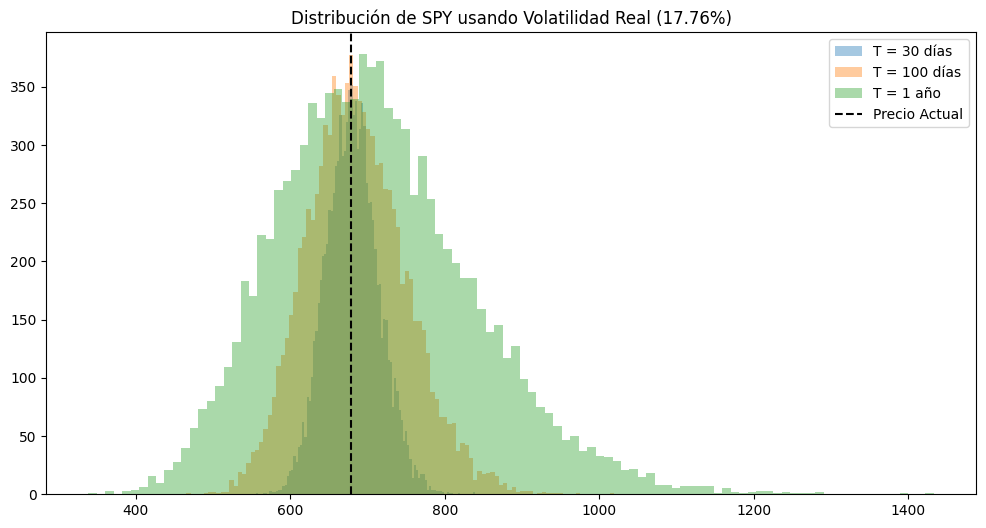


### VALOR DE OPCIONES CON SIGMA REAL ###
Tiempo (T)  Precio Call  Precio Put
   30 días    14.774754   12.444261
  100 días    29.104677   21.392985
     1 año    64.314666   33.412277


In [ ]:
returns = np.log(data / data.shift(1)).dropna()

# Cálculo de Sigma (Desviación estándar anualizada)
# Multiplicamos por sqrt(252) porque hay aprox. 252 días de trading al año
sigma_real = (returns.std() * np.sqrt(252)).item()

# Parámetros Base
S0 = float(data.iloc[-1])
K = S0
r = 0.045
N = 10000
dias = [30, 100, 365]
tiempos_T = [d / 365 for d in dias]
labels_T = ["30 días", "100 días", "1 año"]

print(f"--- Análisis de {ticker} ---")
print(f"Precio Actual (S0): {S0:.2f}")
print(f"Volatilidad Histórica Anualizada (σ): {sigma_real:.2%}")

# 2. Simulación
resultados_T = []
plt.figure(figsize=(12, 6))

for T, label in zip(tiempos_T, labels_T):
    Z = np.random.standard_normal(N)
    # Usamos sigma_real calculada de los precios
    ST = S0 * np.exp((r - 0.5 * sigma_real**2) * T + sigma_real * np.sqrt(T) * Z)

    call_prices = np.exp(-r * T) * np.maximum(ST - K, 0)
    put_prices = np.exp(-r * T) * np.maximum(K - ST, 0)

    resultados_T.append({
        "Tiempo (T)": label,
        "Precio Call": np.mean(call_prices),
        "Precio Put": np.mean(put_prices)
    })

    plt.hist(ST, bins=100, alpha=0.4, label=f'T = {label}')

# 3. Gráfica y Tablas
plt.axvline(S0, color='black', linestyle='--', label='Precio Actual')
plt.title(f'Distribución de {ticker} usando Volatilidad Real ({sigma_real:.2%})')
plt.legend()
plt.show()

df_T = pd.DataFrame(resultados_T)
print("\n### VALOR DE OPCIONES CON SIGMA REAL ###")
print(df_T.to_string(index=False))

Crear una tabla con el valor de la call para cada escenario


In [ ]:
print("\n### TABLA DE VALORES: OPCIÓN CALL POR TIEMPO AL VENCIMIENTO ###")
print(df_T[['Tiempo (T)', 'Precio Call']].to_string(index=False))


### TABLA DE VALORES: OPCIÓN CALL POR TIEMPO AL VENCIMIENTO ###
Tiempo (T)  Precio Call
   30 días    14.774754
  100 días    29.104677
     1 año    64.314666


Crear una tabla con el valor de la put para cada escenario

In [ ]:
print("\n### TABLA DE VALORES: OPCIÓN PUT POR TIEMPO AL VENCIMIENTO ###")
print(df_T[['Tiempo (T)', 'Precio Put']].to_string(index=False))


### TABLA DE VALORES: OPCIÓN PUT POR TIEMPO AL VENCIMIENTO ###
Tiempo (T)  Precio Put
   30 días   12.444261
  100 días   21.392985
     1 año   33.412277


##**Preguntas**
- **¿Cómo cambia la distribución final del precio al aumentar T?**
- Se ensancha y pierde altura genera a mayor tiempo, el activo tiene más margen para desviarse de su precio inicial.

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?**
- Aumenta, debido a que el valor tiempo es mayor dando más oportunidades para que el precio alcance niveles favorables.


#**Actividad 3 — Precio de ejercicio**
Modificar únicamente K.

Probar con:

- K = S0 * 0.70
- K = S0 * 0.90
- K = S0
- K = S0 * 1.10
- K = S0 * 1.30

In [ ]:
S0    = float(data.iloc[-1])
sigma = sigma_real           # calculada en Actividad 2
r     = 0.045
T     = 1.0
N     = 10_000

factores_K = [0.70, 0.90, 1.00, 1.10, 1.30]

# Una sola muestra aleatoria → la única variable que cambia es K
np.random.seed(42)
Z  = np.random.standard_normal(N)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

resultados_K = []
for f in factores_K:
    K_val       = S0 * f
    precio_call = np.exp(-r * T) * np.mean(np.maximum(ST - K_val, 0))
    precio_put  = np.exp(-r * T) * np.mean(np.maximum(K_val - ST, 0))
    resultados_K.append({
        "Factor K":    f"{f:.2f} × S0",
        "Strike K":    round(K_val, 2),
        "Precio Call": round(precio_call, 4),
        "Precio Put":  round(precio_put,  4),
    })

df_K = pd.DataFrame(resultados_K)
print(f"S0 = {S0:.2f}  |  σ = {sigma:.2%}  |  r = {r}  |  T = {T} año")

S0 = 678.27  |  σ = 17.76%  |  r = 0.045  |  T = 1.0 año


/tmp/ipykernel_406/805773498.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0    = float(data.iloc[-1])


Crear una tabla con el valor de la call para cada escenario


In [ ]:
print("\n TABLA CALL — variando K ")
print(df_K[['Factor K', 'Strike K', 'Precio Call']].to_string(index=False))


 TABLA CALL — variando K 
 Factor K  Strike K  Precio Call
0.70 × S0    474.79     224.6086
0.90 × S0    610.44     106.9577
1.00 × S0    678.27      63.3455
1.10 × S0    746.10      33.7232
1.30 × S0    881.75       7.2562


Crear una tabla con el valor de la put para cada escenario

In [ ]:
print("\n TABLA PUT — variando K ")
print(df_K[['Factor K', 'Strike K', 'Precio Put']].to_string(index=False))


 TABLA PUT — variando K 
 Factor K  Strike K  Precio Put
0.70 × S0    474.79      0.4179
0.90 × S0    610.44     12.4518
1.00 × S0    678.27     33.6820
1.10 × S0    746.10     68.9022
1.30 × S0    881.75    172.1201


##**Preguntas**
- **¿Aumenta o disminuye el valor de la opción conforme aumenta K?**

La call disminuye, esto se debe a que un strike más alto hace que sea menos probable que el precio final ST supere K, por lo que el derecho a comprar vale menos.


La put aumenta porque un strike más alto significa que el derecho a vender a ese precio es más valioso, porque hay más margen de ganancia si ST cae por debajo de K.


- **¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?**

Cuando se tiene un strike muy bajo (K = 0.70×S0), la call vale mucho (está profundamente ITM, casi seguro ejerces) y la put vale casi cero (tendrías que vender por debajo del precio actual, muy improbable que ganes).


Cuando se tiene un strike muy alto (K = 1.30×S0), la call vale casi cero (necesitarías un rally enorme), la put vale mucho (estás cubierto ante una caída fuerte).



#**Actividad 4 — Tasa libre de riesgo**
Modificar únicamente r.

Probar con:

- r = 0.01
- r = 0.05
- r = 0.10

**Graficar**:

1- Distribución final del precio Spot

/tmp/ipykernel_406/2494880739.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0    = float(data.iloc[-1])


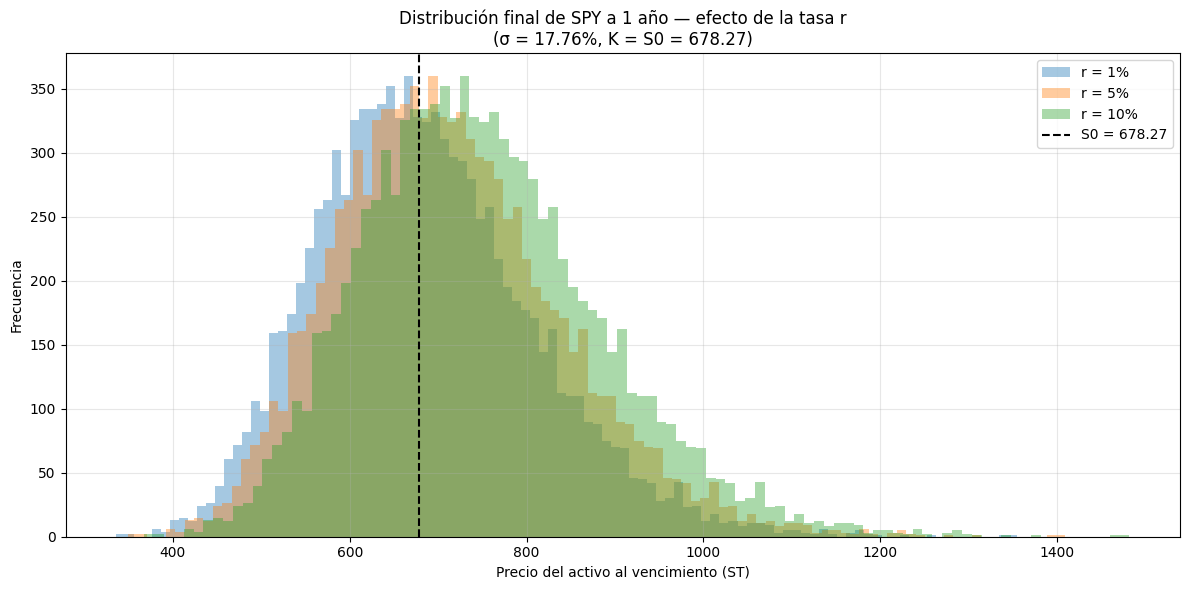

In [ ]:
S0    = float(data.iloc[-1])
K     = S0            # at-the-money
sigma = sigma_real
T     = 1.0
N     = 10_000

tasas_r = [0.01, 0.05, 0.10]

resultados_r = []
plt.figure(figsize=(12, 6))

for r_val in tasas_r:
    np.random.seed(42)   # misma semilla → solo cambia r
    Z  = np.random.standard_normal(N)
    ST = S0 * np.exp((r_val - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    precio_call = np.exp(-r_val * T) * np.mean(np.maximum(ST - K, 0))
    precio_put  = np.exp(-r_val * T) * np.mean(np.maximum(K - ST, 0))

    resultados_r.append({
        "Tasa r":             r_val,
        "Media ST esperada":  round(np.mean(ST), 2),
        "Precio Call":        round(precio_call, 4),
        "Precio Put":         round(precio_put,  4),
    })

    plt.hist(ST, bins=100, alpha=0.4, label=f'r = {r_val:.0%}')

plt.axvline(S0, color='black', linestyle='--', linewidth=1.5,
            label=f'S0 = {S0:.2f}')
plt.title(f'Distribución final de {ticker} a 1 año — efecto de la tasa r\n'
          f'(σ = {sigma:.2%}, K = S0 = {S0:.2f})')
plt.xlabel('Precio del activo al vencimiento (ST)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_r = pd.DataFrame(resultados_r)

Crear una tabla con el valor de la call para cada escenario



In [ ]:
print("\n TABLA CALL — variando r ")
print(df_r[['Tasa r', 'Media ST esperada', 'Precio Call']].to_string(index=False))


 TABLA CALL — variando r 
 Tasa r  Media ST esperada  Precio Call
   0.01             684.90      51.2066
   0.05             712.85      65.1851
   0.10             749.40      84.9735


Crear una tabla con el valor de la put para cada escenario

In [ ]:
print("\n TABLA PUT — variando r ")
print(df_r[['Tasa r', 'Media ST esperada', 'Precio Put']].to_string(index=False))


 TABLA PUT — variando r 
 Tasa r  Media ST esperada  Precio Put
   0.01             684.90     44.6399
   0.05             712.85     32.2876
   0.10             749.40     20.6097


##**Preguntas**
- **¿Cómo cambia el crecimiento esperado del precio del activo?**

La tasa r aparece en el drift del modelo GBM. Es decir, a mayor r el crecimiento esperado de ST es mayor y la distribución entera se desplaza hacia la derecha (el histograma de r=10% está más a la derecha que el de r=1%).

- **¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?**

Cuando aumenta la tasa libre de riesgo la call sube. El drift más alto empuja ST hacia arriba, aumentando la probabilidad de que ST > K. Este efecto domina sobre el mayor descuento, por lo que el precio de la call crece con r.

- **¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?**

Cuando aumenta la tasa libre de riesgo la put baja. El doble efecto negativo la golpea, haciendo que ST suba en promedio, reduciendo la probabilidad de ejercer la put. Asimismo, el factor de descuento e^(-r·T) es menor, reduciendo el valor presente del payoff. Ambos efectos van en la misma dirección.
